# DEEP LEARNING GSLC 2

the dataset that we're gonna use from kaggle is climate change in Delhi

find the dataset in this link --> https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data


the dataset has 5 columns

- date : in format YYYY-MM-DD
- meantemp: Mean temperature averaged out from multiple 3 hour intervals in a day
- humidity : Humidity value for the day (units are grams of water vapor per cubic meter volume of air)
- wind_speed: Wind speed measured in kmph (kilometres per hour)
- meanpressure: Pressure reading of weather (measure in atm) (atmosphere)

## The Objective?

Train a Recurrent Neural Network model for a time-series forecasting case with an output sequence length of 1.

You can use any datasets including the ones used in the 2 examples.

Build 1 RNN model with at least 2 recurrent layers & 1 input covariate (10%)

Perform EDA to analyze the trends & seasonality (10%)

Preprocess the data (10%), train (5%)

Evaluate the models (5%)!

Analyze the evaluation results (10%)! Use markdowns to explain your codes.

You can also use LSTM or GRU layers.

### Load Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

from datetime import datetime

### Load Dataset

the dataset from kaggle already came in separated csv
- DailyDelhiClimateTest.csv
- DailyDelhiClimateTrain.csv

so we already need to load them into separate datasets

In [3]:
train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

In [4]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


we have to preprocess both data separately instead of comibing the 2 into one dataset in order to prevent any data leakage

#### Train Dataset Preprocessing

In [6]:
train_df.shape

(1462, 5)

In [7]:
train_df.dtypes

,0
date,object
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [9]:
train_df.describe(include = "all")

,date,meantemp,humidity,wind_speed,meanpressure
count,1462,1462.000000,1462.000000,1462.000000,1462.000000
unique,1462,NaN,NaN,NaN,NaN
top,2017-01-01,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,25.495521,60.771702,6.802209,1011.104548
std,NaN,7.348103,16.769652,4.561602,180.231668
min,NaN,6.000000,13.428571,0.000000,-3.041667
25%,NaN,18.857143,50.375000,3.475000,1001.580357
50%,NaN,27.714286,62.625000,6.221667,1008.563492
75%,NaN,31.305804,72.218750,9.238235,1014.944901


since date is still categorised as an object, we have to covert it into a datetime datatype

meanwhile the other variables have the correct data types

meantemp	float64

humidity	float64

wind_speed	float64

meanpressure	float64


In [10]:
train_df['date'] = pd.to_datetime(train_df['date'])

In [11]:
train_df.dtypes

,0
date,datetime64[ns]
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


the dataset is consistent, there are no invalid values or strings such as "NA", "-", or " " to replace any missing values, so no string spacing consistency or invalid string vallues must be checked

In [12]:
train_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [13]:
train_df.duplicated().sum()

np.int64(0)

In [14]:
train_df.nunique()

,0
date,1462
meantemp,617
humidity,897
wind_speed,730
meanpressure,626


In [15]:
train_df.shape

(1462, 5)

it is expected for the date variable to have 1462 unique values, and since the total number of columns in the dataset is also 1462, this means that each no row had the same date

In [16]:
train_df.columns # just to look at the name of the columns again

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')

since we want to evaluate the model by plotting train log loss and validation log loss,

im just going to split the training dataset to
- 80% training
- 20% validation

the test dataset is already small enough that splitting it into 80:20 will give very small data for the model to work with, it may not be enough to draw a valid conclusion from the lack of representation

In [17]:
train_size = int(len(train_df) * 0.8)

val_df = train_df[train_size:]
train_df = train_df[:train_size]

In [18]:
print(train_df.shape)
print(val_df.shape)

(1169, 5)
(293, 5)


#### Test Dataset Preprocessing

In [19]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [20]:
test_df.shape

(114, 5)

In [21]:
test_df.dtypes

,0
date,object
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [23]:
test_df.describe(include = "all")

,date,meantemp,humidity,wind_speed,meanpressure
count,114,114.000000,114.000000,114.000000,114.000000
unique,114,NaN,NaN,NaN,NaN
top,2017-01-01,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,21.713079,56.258362,8.143924,1004.035090
std,NaN,6.360072,19.068083,3.588049,89.474692
min,NaN,11.000000,17.750000,1.387500,59.000000
25%,NaN,16.437198,39.625000,5.563542,1007.437500
50%,NaN,19.875000,57.750000,8.069444,1012.739316
75%,NaN,27.705357,71.902778,10.068750,1016.739583


the date datatype in the test dataframe is also still classified as object, so change it into the datetime datatype

In [24]:
test_df['date'] = pd.to_datetime(test_df['date'])

In [25]:
test_df.dtypes

,0
date,datetime64[ns]
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


the other variables have the datatype consistent with the training dataset which was already appropriate

meantemp	float64

humidity	float64

wind_speed	float64

meanpressure	float64


column name is also consistent with training dataset

In [26]:
test_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [27]:
test_df.duplicated().sum()

np.int64(0)

In [28]:
test_df.nunique()

,0
date,114
meantemp,105
humidity,109
wind_speed,109
meanpressure,109


In [29]:
test_df.shape

(114, 5)

In [30]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


### EDA

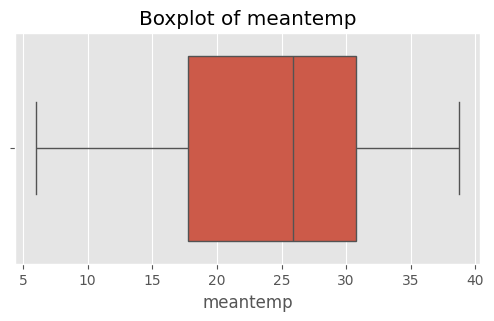

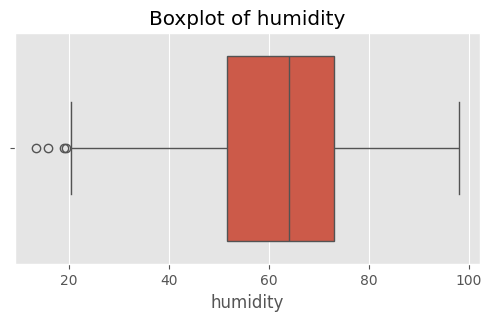

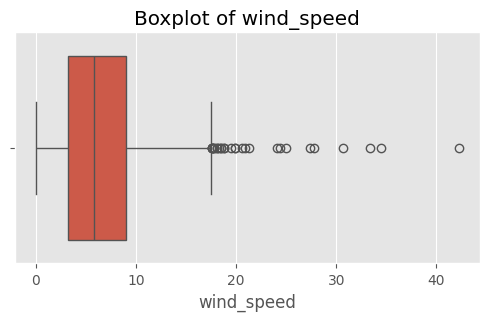

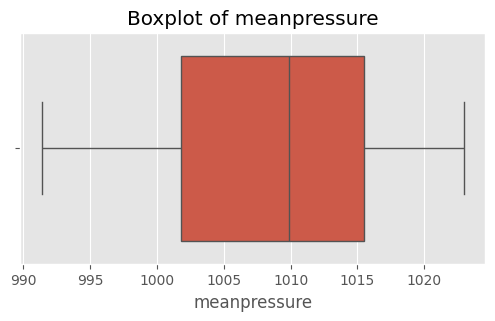

In [31]:
numerical_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


through these boxplots, we can only see that only wind_speed has some outliers that extend further than the max Q4 line

when dealing with weather dataset, sometimes outliers can indicate seasonal trends of extreme temperatures, storms/highwinds, drought or even typhoons


In [32]:
train_df.describe()

,date,meantemp,humidity,wind_speed,meanpressure
count,1169,1169.000000,1169.000000,1169.000000,1169.000000
mean,2014-08-08 00:00:00,24.558212,61.862907,6.601609,1008.754820
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,991.375000
25%,2013-10-20 00:00:00,17.769231,51.625000,3.237500,1001.833333
50%,2014-08-08 00:00:00,25.875000,64.000000,5.814286,1009.875000
75%,2015-05-27 00:00:00,30.750000,73.000000,8.950000,1015.500000
max,2016-03-14 00:00:00,38.714286,98.000000,42.220000,1023.000000
std,NaN,7.424363,16.530145,4.664345,7.628490


in terms of invalid values, like unreasonable values eg: humidity of -20

there are no invalid values when checking through the max and min of each variable, all maximum and minimum values are within range of realistic data

In [33]:
corr_data = train_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']]
corr_matrix = corr_data.corr()

In [34]:
corr_matrix

,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.593270,0.303802,-0.889802
humidity,-0.593270,1.000000,-0.362496,0.378335
wind_speed,0.303802,-0.362496,1.000000,-0.298244
meanpressure,-0.889802,0.378335,-0.298244,1.000000


In [35]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


### Seasonality Plot

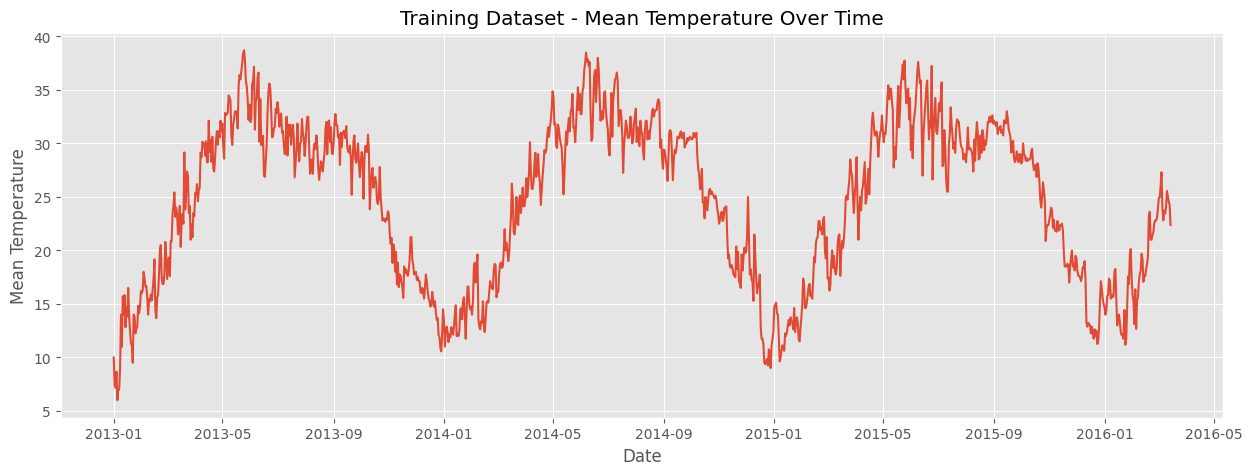

In [36]:
plt.figure(figsize=(15, 5))

plt.plot(
    train_df['date'],
    train_df['meantemp'])
plt.title('Training Dataset - Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')

plt.show()

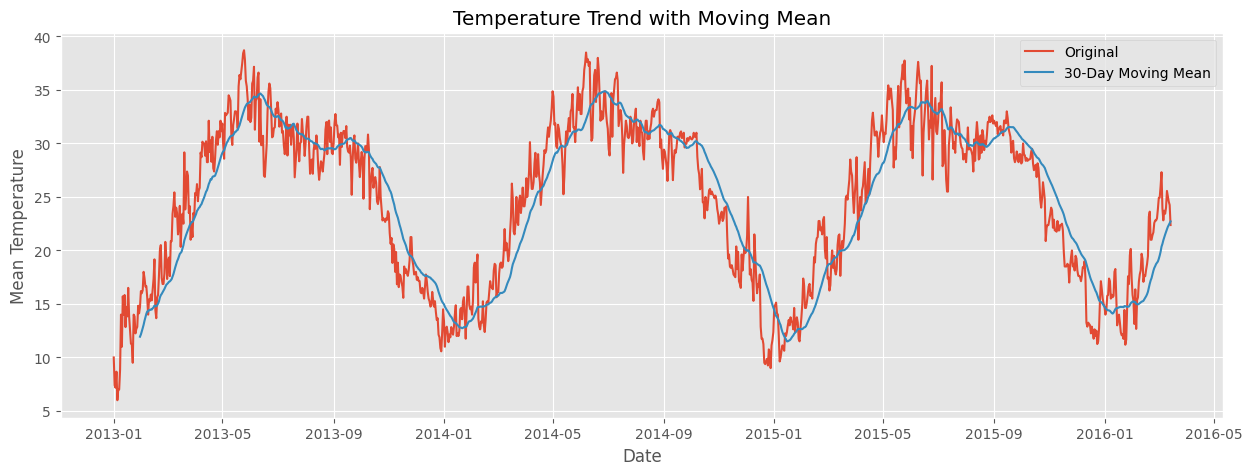

In [37]:
plt.figure(figsize=(15, 5))

plt.plot(
    train_df['date'],
    train_df['meantemp'],
    label='Original'
)

plt.plot(
    train_df['date'],
    train_df['meantemp'].rolling(window=30).mean(),
    label='30-Day Moving Mean'
)

plt.title('Temperature Trend with Moving Mean')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.legend()

plt.show()

in this plot the moving mean can also be interpreted as rolling mean. we can use it to minimize the smaller fluctuation in a time series into a line that shows the moving average over every 30 days.

from this graph we can see a clear trend where the temperature rises at the beginning of each year, peaks at the middle of each year and falls at the end.

with a similar slight increase at the 10th month

if i do search on google, "why does delhi temperature slightly rise in october"

it tells us that Delhi goes through something called "October Heat", where there is a transitional weather phenomenon

in which monsoon withdraws, resulting in clear skies and high humidity lead to a rise in maximum temperature

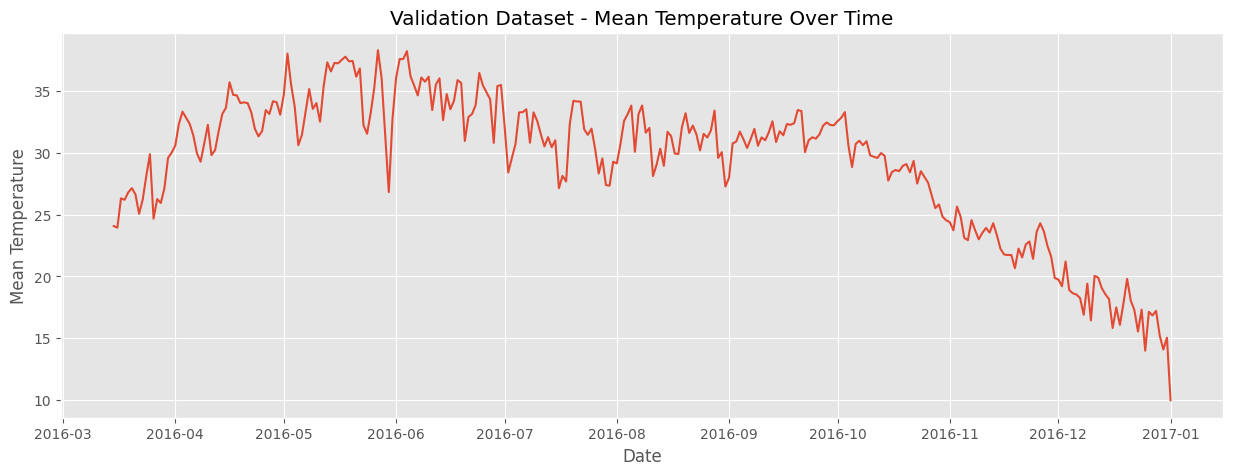

In [38]:
plt.figure(figsize=(15, 5))

plt.plot(
    val_df['date'],
    val_df['meantemp']
)
plt.title('Validation Dataset - Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.show()

validation dataset is split of a smaller training set, which is why the plot looks different but is just a smaller, zoomed in part of the split training dataset

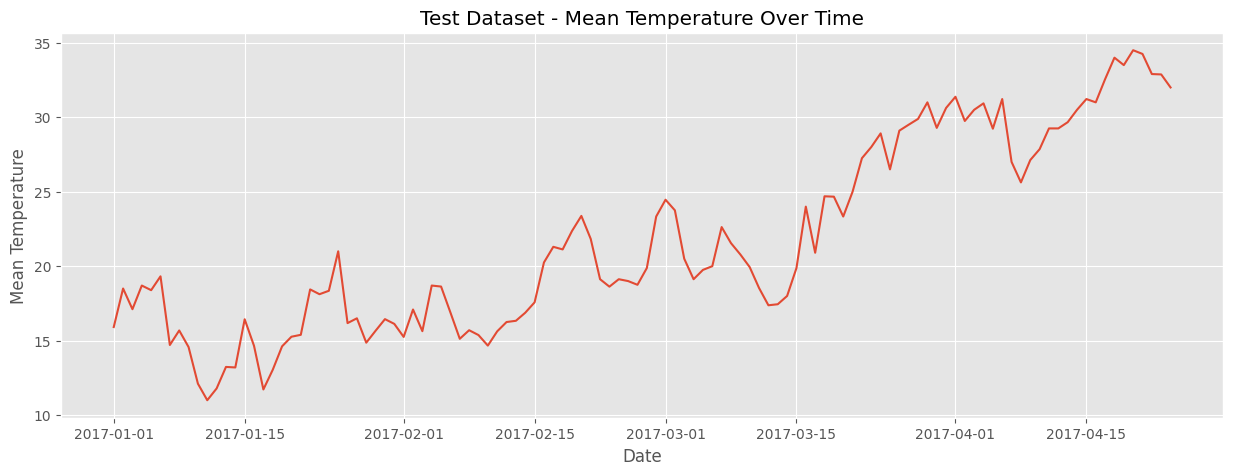

In [39]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df['date'],
    test_df['meantemp']
)

plt.title('Test Dataset - Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')

plt.show()

this plot also look different compared to the training dataset with the same reason as the validation dataset, except the training dataset was already split from a different CSV in the beginning


### Feature Engineering

for this dataset i thought it would be good to separate the month and day of the date variable because the month can be useful in catching yealy seasonality and day of the week can capture weekly patterns, this way the model might learn seasonal months or how the day's temperature is affected by the previous days

we do this to all of the dataset that we have: train, test and val

In [40]:
train_df['month'] = train_df['date'].dt.month
val_df['month'] = val_df['date'].dt.month
test_df['month'] = test_df['date'].dt.month

In [41]:
train_df['day'] = train_df['date'].dt.day
val_df['day'] = val_df['date'].dt.day
test_df['day'] = test_df['date'].dt.day

In [42]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,month,day
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,1,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,1,2
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,1,3
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,1,4
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,1,5


In [43]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,month,day
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,1,1
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,1,2
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,1,3
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,1,4
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,1,5


### Feature Scaling

In [44]:
feature_cols = [
    'meantemp',
    'humidity',
    'wind_speed',
    'meanpressure',
    'month',
    'day'
]

note that we dont include the date in feature cols, because it only shows the time concepts it is not the needed feature that contributes to the trend. if we're concerned about month and days for seasonality, the columns were already made during feature engineering

In [45]:
scaler = MinMaxScaler()

In [46]:
train_scaled = scaler.fit_transform(train_df[feature_cols])

we use min max scaler only for the training data to prevent any further data leakage


model should only learn from past information in the training dataset. If the scaler is fitted using validation or test data, the model can indirectly gain information about future values


min max scaler is used for season climate data because our features are ranged from very different scales, meanwhile min max scaler transforms them into numbers between 0 and 1 which could prevent large-valued features from dominating smaller-valued ones


validation and testing dataset will only be transformed to use the same scaling parameters learned from training data

In [47]:
val_scaled = scaler.transform(val_df[feature_cols])

test_scaled = scaler.transform(test_df[feature_cols])

since this results in a scaled array so we have to turn it back into a dataframe and combine it with the date that was not transformed

In [48]:
train_scaled_df = pd.DataFrame(
    train_scaled,
    columns=feature_cols,
    index=train_df.index
)

val_scaled_df = pd.DataFrame(
    val_scaled,
    columns=feature_cols,
    index=val_df.index
)

test_scaled_df = pd.DataFrame(
    test_scaled,
    columns=feature_cols,
    index=test_df.index
)

In [49]:
train_scaled_df.head()

,meantemp,humidity,wind_speed,meanpressure,month,day
0,0.122271,0.840372,0.000000,0.768116,0.0,0.000000
1,0.042795,0.929054,0.070583,0.835573,0.0,0.033333
2,0.035662,0.869932,0.109743,0.862978,0.0,0.066667
3,0.081514,0.684685,0.029212,0.815547,0.0,0.100000
4,0.000000,0.867962,0.087636,0.794466,0.0,0.133333


In [50]:
train_scaled_df['date'] = train_df['date'].values
train_scaled_df = train_scaled_df[['date'] + feature_cols]

val_scaled_df['date'] = val_df['date'].values
val_scaled_df = val_scaled_df[['date'] + feature_cols]

test_scaled_df['date'] = test_df['date'].values
test_scaled_df = test_scaled_df[['date'] + feature_cols]

then append the dates back into the scaled dataframe

In [51]:
train_scaled_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,month,day
0,2013-01-01,0.122271,0.840372,0.000000,0.768116,0.0,0.000000
1,2013-01-02,0.042795,0.929054,0.070583,0.835573,0.0,0.033333
2,2013-01-03,0.035662,0.869932,0.109743,0.862978,0.0,0.066667
3,2013-01-04,0.081514,0.684685,0.029212,0.815547,0.0,0.100000
4,2013-01-05,0.000000,0.867962,0.087636,0.794466,0.0,0.133333


In [52]:
val_scaled_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,month,day
1169,2016-03-15,0.552256,0.538063,0.204800,0.742819,0.181818,0.466667
1170,2016-03-16,0.548308,0.476774,0.257727,0.677866,0.181818,0.500000
1171,2016-03-17,0.620906,0.436128,0.162097,0.602767,0.181818,0.533333
1172,2016-03-18,0.617085,0.565456,0.158989,0.583004,0.181818,0.566667
1173,2016-03-19,0.635371,0.572635,0.084760,0.564088,0.181818,0.600000


In [53]:
test_scaled_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,month,day
0,2017-01-01,0.303019,0.856566,0.064981,-29.482213,0.0,0.000000
1,2017-01-02,0.382096,0.754317,0.068556,0.850681,0.0,0.033333
2,2017-01-03,0.339641,0.809497,0.095137,0.852437,0.0,0.066667
3,2017-01-04,0.388210,0.669510,0.107650,0.769170,0.0,0.100000
4,2017-01-05,0.378700,0.727384,0.078162,0.725955,0.0,0.133333


### Sequence Creation

In [54]:
sequence_length = 30
target_col = 'meantemp'

define X and y based on the sequence

In [55]:
def create_sequences(data, sequence_length, target_index):

    X = []
    y = []

    for i in range(sequence_length, len(data)):

        X.append(
            data[i-sequence_length:i])

        y.append(
            data[i, target_index])

    return np.array(X), np.array(y)

In [56]:
train_array = train_scaled_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].values

val_array = val_scaled_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].values

test_array = test_scaled_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].values


In [57]:
target_index = 0

make the sequence needed for all dataframes

In [58]:
X_train, y_train = create_sequences(
    train_array,
    sequence_length,
    target_index)

X_val, y_val = create_sequences(
    val_array,
    sequence_length,
    target_index)

X_test, y_test = create_sequences(
    test_array,
    sequence_length,
    target_index)

In [59]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1139, 30, 4)
y_train shape: (1139,)

X_val shape: (263, 30, 4)
y_val shape: (263,)

X_test shape: (84, 30, 4)
y_test shape: (84,)


### Build LSTM model

In [60]:
model = Sequential()

#for 1st layer
model.add(
    LSTM(
        units=32,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2])
    )
)


model.add(Dropout(0.2))


#2nd lstm layer
model.add(LSTM(units=16))


model.add(Dropout(0.2))

#output
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 32)         │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,889 (30.82 KB)

 Trainable params: 7,889 (30.82 KB)

 Non-trainable params: 0 (0.00 B)

#### training the model

In [62]:
#stop training if val loss doesnt improve --> model already stop learning, stops some overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [63]:
historymodel = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.1112 - mae: 0.2648 - val_loss: 0.0356 - val_mae: 0.1548
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0197 - mae: 0.1126 - val_loss: 0.0179 - val_mae: 0.1012
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0167 - mae: 0.1030 - val_loss: 0.0138 - val_mae: 0.0866
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0141 - mae: 0.0946 - val_loss: 0.0157 - val_mae: 0.0930
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0131 - mae: 0.0913 - val_loss: 0.0141 - val_mae: 0.0870
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0122 - mae: 0.0874 - val_loss: 0.0152 - val_mae: 0.0925
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0128 - mae: 0.0886 - val_loss: 0.0134 - val_mae: 0.0858
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0127 - mae: 0.0901 - val_loss: 0.0158 - val_mae: 0.0964
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.012

the lesser amount of epochs, patience and the lesser amount of LSTM layers are due to the fact that the training runs very slowly on my device when i used larger params

### Evaluation

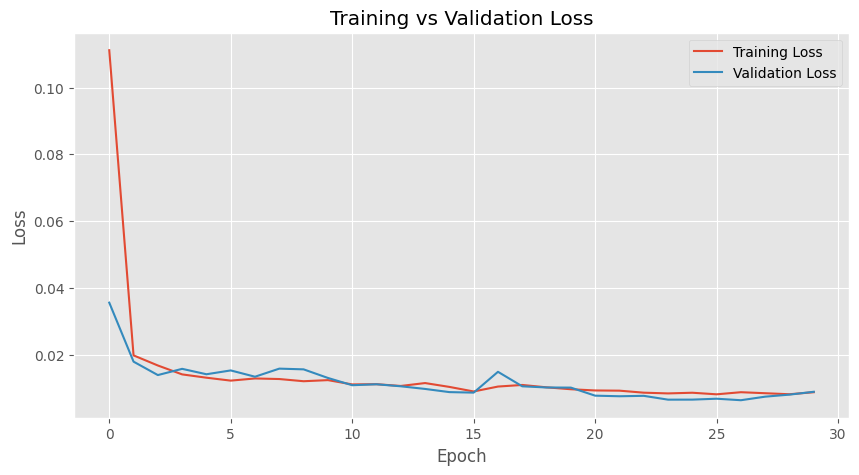

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    historymodel.history['loss'],
    label='Training Loss')

plt.plot(
    historymodel.history['val_loss'],
    label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [65]:
test_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


from the last epoch and the training and validation loss graph

Epoch 30/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0087 - mae: 0.0726 - val_loss: 0.0088 - val_mae: 0.0758


the model learned both patterns in training and validation as both of their plots decrease. LSTM learned both the sequential climate behaviour, temperature dependencies with month and day and the relationship between temperature and other features like humidity, windspeed and pressure

the steep drop during the first few epochs shows that the model learned forecasting patterns relatively quick and the dataset showed strong temporal patterns

the validation loss throughout each epochs are relatively low and stable, the model performs consistently well in unseen data.


both the training loss and validation loss curve decrease with each other and stays close after the big drop, there are no significant signs of overfitting.

model can converge properly, as the graphs slows down in improvement and eventually flattens and stops when epoch validation loss stops improving.

#### inverse scaling

In [66]:
def inverse_transform_target(scaled_values):

    dummy = np.zeros(
        (len(scaled_values), len(feature_cols))
    )

    dummy[:, 0] = scaled_values.flatten()
    inverted = scaler.inverse_transform(dummy)

    return inverted[:, 0]

#### inverse transform predictions

In [67]:
test_pred_inv = inverse_transform_target(test_pred)

#### inverse transform actual values

In [68]:
y_test_inv = inverse_transform_target(y_test.reshape(-1, 1))

we had to inverse scale the predicted values and into the actual values, because from the scaled MinMax transformation, we want to convert it back into its original scale and units in order to do evaluation metrics calculations. so we can use that initial unit and measurement for comparison for a relatively "large" or "small" error

#### evaluation metrics

In [69]:
mae = mean_absolute_error(
    y_test_inv,
    test_pred_inv)

mse = mean_squared_error(
    y_test_inv,
    test_pred_inv
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_inv,
    test_pred_inv
)

In [70]:
print("from test")
print("MAE in degrees C:", mae)
print("MSE :", mse)
print("RMSE in degrees C:", rmse)
print("R² Score :", r2)

from test
MAE in degrees C: 2.182915664612224
MSE : 6.8316215216308835
RMSE in degrees C: 2.6137370796679003
R² Score : 0.8032552577407138


In terms of MAE, MSE, RMSE metrics

MAE  = 2.22 °C

MSE  = 7.00

RMSE = 2.65 °C

R²   = 0.798


basically the LSTM model takes in the feature variables and data from 30 previous days to learn the pattern, and update its own hidden states for sequential learning.

An MAE of 2.2 degrees C means that on average, the model's temperature predictions can differ from the actual temperature by 2.2 degrees. In real world climate forecasting this is a relatively decent number.

an MSE of the model penalise errors more heavily because the errors are squared. getting a 7.00 can show us that overall the prediction errors are relatively within range, but there might be some bigger deviations during sudden temperature changes during certain seasons.


the RMSE is at 2.65 degrees c which means that the model's error is usually around 2.65, since it squares the errors first, and bigger error makes a larger difference. But since the RMSE and MAE does not differ largely ~ 0.45 degrees C, then the extreme prediction errors are also not that frequent and is still relatively consistent.


The R^2 value is 0.798 which means the model could explain 79.8% of the temperature variability. the model was able to capture ~80% of the variance and properly use them for predictions

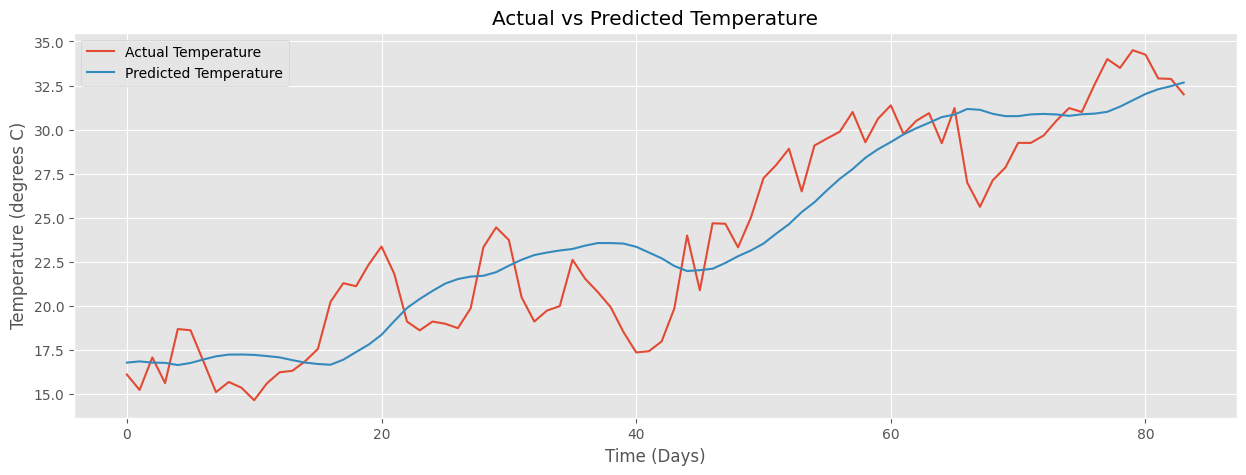

In [71]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_inv,
    label='Actual Temperature')

plt.plot(
    test_pred_inv,
    label='Predicted Temperature')

plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time (Days)')
plt.ylabel('Temperature (degrees C)')
plt.legend()

plt.show()

going back to the MSE explanation, it is visible in the graph that the temperature can spike or drop sharply, however the model predictions tend to predict a smoother trend, however if we look at the deviations

in day 20, the temperature differs

actual value: 23.75
predicted value: 18.75

the model still make mistakes, in here there's a 5 degree difference with the actual value



in terms of trend or seasonal progression, the predicted curve is much smoother than the actual value curve. looking at the big picture, the model does capture the overall trend of the actual data. The predicted graph is a smoother curve because the model was aiming to generalise the data. LSTM tend to learn larger temporal trends in general, so when climate data have some sudden atmospheric changes, spikes or noise, the model did not capture it. some very sharp fitting can raise the question of an overfitting model.

However the model was able to generalise well, shown by the validation loss that remained stable (back up in the training to validation loss graph). and there are no big fluctuations or divergences in train and validation loss graph.
